# Assignment: Week 13 - Decision Tree and Random Forest

## Summary
#### In this project we analyze publicly available loan data from www.lendingclub.com to build a predictive model that can classify whether or not a borrower is likely to pay back their loan in full.


## Step 1: Import necessary libraries and Load the dataset

In [1]:
# importing libraries
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt, seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("lending_club.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   object 
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  not.fully.paid     9578 non-null   int64  
dtypes: float64(6), int64(7), object(1)
memory usage: 1.0+ MB


In [4]:
df.describe()

,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
count,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9.578000e+03,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000
mean,0.804970,0.122640,319.089413,10.932117,12.606679,710.846314,4560.767197,1.691396e+04,46.799236,1.577469,0.163708,0.062122,0.160054
std,0.396245,0.026847,207.071301,0.614813,6.883970,37.970537,2496.930377,3.375619e+04,29.014417,2.200245,0.546215,0.262126,0.366676
min,0.000000,0.060000,15.670000,7.547502,0.000000,612.000000,178.958333,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.103900,163.770000,10.558414,7.212500,682.000000,2820.000000,3.187000e+03,22.600000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.122100,268.950000,10.928884,12.665000,707.000000,4139.958333,8.596000e+03,46.300000,1.000000,0.000000,0.000000,0.000000
75%,1.000000,0.140700,432.762500,11.291293,17.950000,737.000000,5730.000000,1.824950e+04,70.900000,2.000000,0.000000,0.000000,0.000000
max,1.000000,0.216400,940.140000,14.528354,29.960000,827.000000,17639.958330,1.207359e+06,119.000000,33.000000,13.000000,5.000000,1.000000


In [5]:
df.head()

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


In [6]:
# Checking for impbalance
df['not.fully.paid'].value_counts()

not.fully.paid
0    8045
1    1533
Name: count, dtype: int64

Text(0.5, 0, 'FICO')

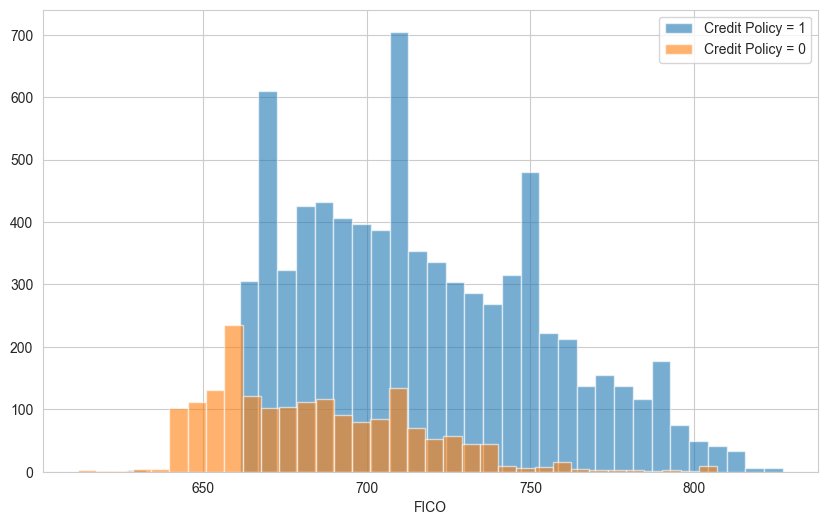

In [7]:
# FICO Distributions by Credit Policy 
plt.figure(figsize=(10,6))
sns.set_style('whitegrid') # This adds the grid lines seen in the PDF
df[df['credit.policy']==1]['fico'].hist(bins=35, label='Credit Policy = 1', alpha=0.6)
df[df['credit.policy']==0]['fico'].hist(bins=35, label='Credit Policy = 0', alpha=0.6)
plt.legend()
plt.xlabel('FICO')

Text(0.5, 0, 'FICO')

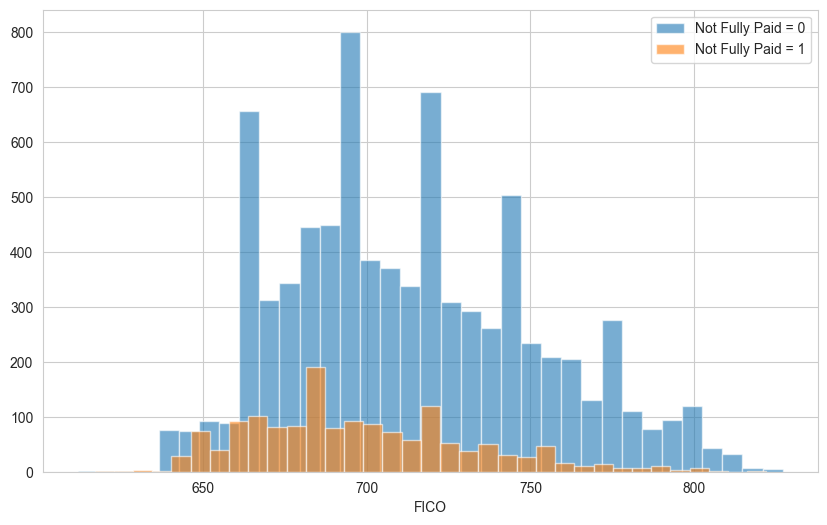

In [8]:
# FICO Distributions by Not Fully Paid
plt.figure(figsize=(10,6))
df[df['not.fully.paid']==0]['fico'].hist(bins=35, label='Not Fully Paid = 0', alpha=0.6)
df[df['not.fully.paid']==1]['fico'].hist(bins=35, label='Not Fully Paid = 1', alpha=0.6)
plt.legend()
plt.xlabel('FICO')

<Axes: xlabel='purpose', ylabel='count'>

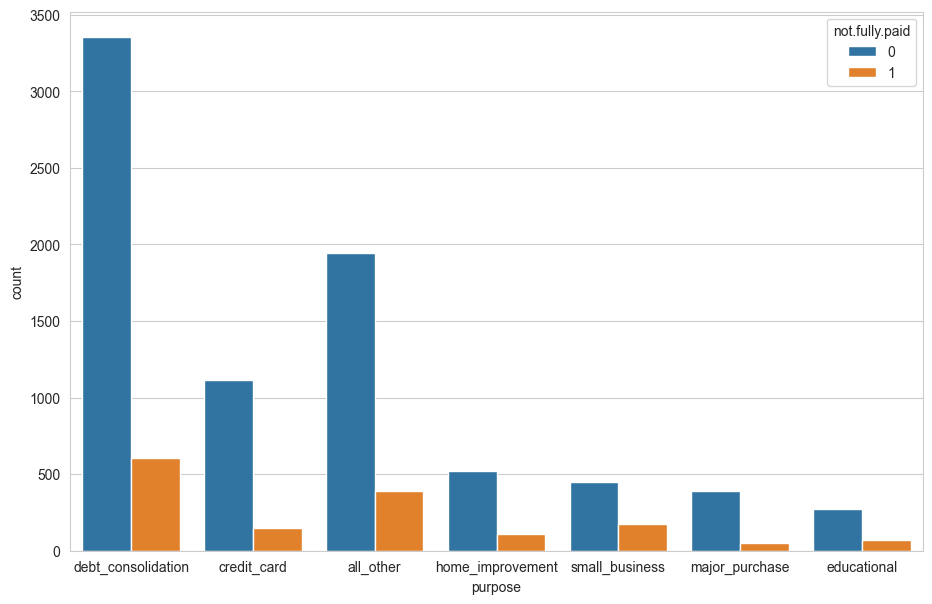

In [9]:
# Count Loans by Purpose
plt.figure(figsize=(11, 7))
sns.countplot(x='purpose', hue='not.fully.paid', data=df)

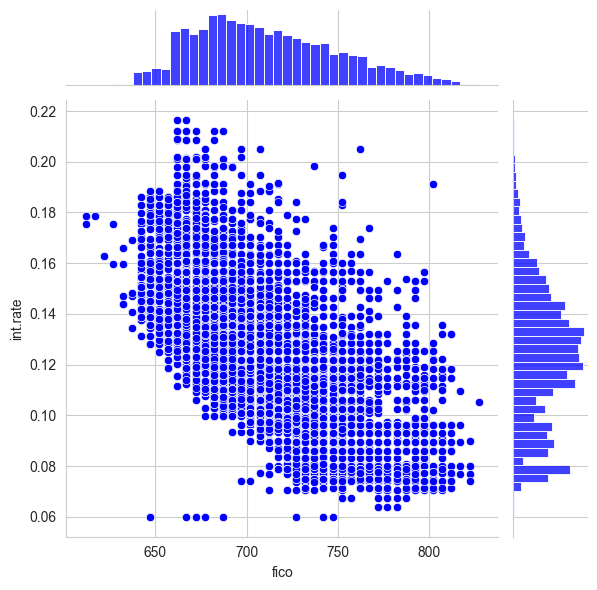

In [10]:
# Trend between FICO score and Interest Rate
sns.jointplot(x='fico', y='int.rate', data=df, color='blue')

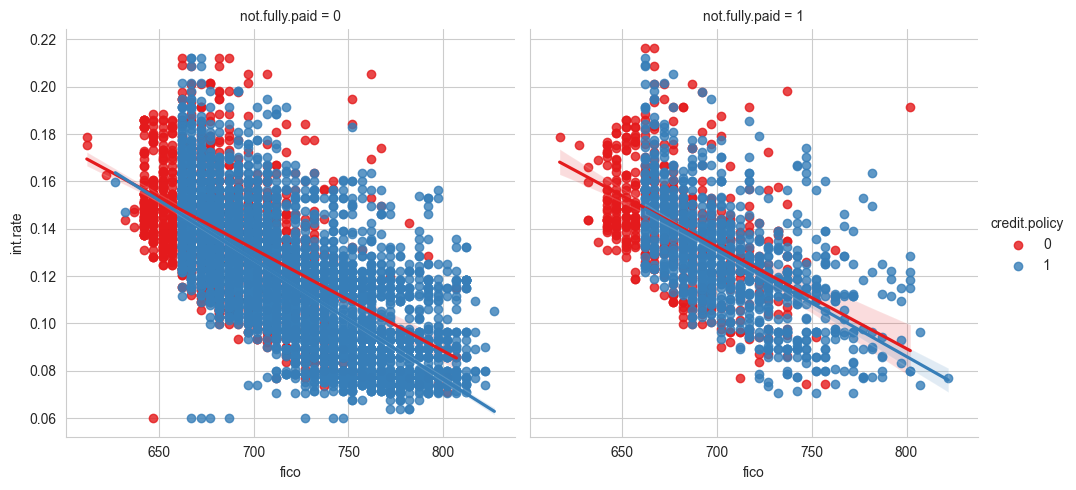

In [11]:
# Trend between Not Fully Paid and Credit Policy
sns.lmplot(y='int.rate', x='fico', data=df, hue='credit.policy', 
           col='not.fully.paid', palette='Set1')

In [12]:
# Unique values for purpose
print(df['purpose'].unique())

['debt_consolidation' 'credit_card' 'all_other' 'home_improvement'
 'small_business' 'major_purchase' 'educational']


In [13]:
# Handle Categorical Columns
cat_feats = ['purpose']

In [14]:
df.drop('not.fully.paid', axis=1).iloc[0].values

array([1, 'debt_consolidation', 0.1189, 829.1, 11.35040654, 19.48, 737,
       5639.958333, 28854, 52.1, 0, 0, 0], dtype=object)

In [15]:
ct = ColumnTransformer(
    [('encoder', OneHotEncoder(drop=['small_business']), [1])], 
    remainder='passthrough'
)
X = ct.fit_transform(df.drop('not.fully.paid', axis=1))
X[0].astype(object)

array([0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.1189, 829.1, 11.35040654,
       19.48, 737.0, 5639.958333, 28854.0, 52.1, 0.0, 0.0, 0.0],
      dtype=object)

In [16]:
# Train/Test Split Decision Tree
y = df['not.fully.paid'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=101)
dtree = DecisionTreeClassifier(class_weight='balanced')
dtree.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced')

In [17]:
# Decision Tree Prediction and Evaluation
predictions = dtree.predict(X_test)
print(classification_report(y_test, predictions))
print(confusion_matrix(y_test, predictions))

              precision    recall  f1-score   support

           0       0.85      0.84      0.85      2029
           1       0.18      0.19      0.18       366

    accuracy                           0.74      2395
   macro avg       0.51      0.52      0.51      2395
weighted avg       0.75      0.74      0.75      2395

[[1709  320]
 [ 297   69]]


In [18]:
# Random Forest Prediction and Evaluation
rf = RandomForestClassifier(n_estimators=600, class_weight='balanced')

In [19]:
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=600)

In [20]:
rfpredictions = rf.predict(X_test)

In [21]:
print(classification_report(y_test, rfpredictions))
print(confusion_matrix(y_test, rfpredictions))

              precision    recall  f1-score   support

           0       0.85      1.00      0.92      2029
           1       0.50      0.00      0.01       366

    accuracy                           0.85      2395
   macro avg       0.67      0.50      0.46      2395
weighted avg       0.79      0.85      0.78      2395

[[2028    1]
 [ 365    1]]


## Summary
### The Random Forest has a higher overall accuracy of 85% but fails to identify the risky loans, it only identified 1. The Decision Tree correctly flags more potential defaults 69, but its  accuracy is lower at 72%.

## Bonus
### To solve the class imbalance, we used the class_weight='balanced' parameter.